In [232]:
from operator import index

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from math import nan as NaN
import numpy as np
import statsmodels
import plotly.express as px
import plotly.io as pio
from IPython.display import IFrame
import os
pio.renderers.default = "iframe"
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)
#Zmienne pomocnicze
rent_limit = 20
center_lat = 50.049683
center_lon = 19.944544

In [385]:
df = pd.read_csv('../data/master_listings.csv', sep=';')

In [390]:
dynamic_threshold = df['price'].quantile(0.0015)
floor_order = ['Unknown','Basement', 'Ground Floor', '1', '2', '3', '4', '5', '6', '7', '8', '9','10', '10+', 'Attic', ]
floor_map={
    '0':'Ground Floor',
    'higher_10':'10+',
    'cellar':'Basement',
    'garret':'Attic'
    
}

In [383]:
#Pomocnicza funkcja formatująca
def format_millions(x, pos):
    if x >= 1000000:
        return f'{x / 1000000:.1f}M'
    elif x >= 1000:
        return f'{x / 1000:.1f}K'
    else:
        return str(int(x))
#Porządek kategorii pokojów
correct_order = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'More than 10']

# Inspekcja

In [160]:
df.tail()

,_id,agency__id,agency_city,agency_county,agency_name,agency_otodom_id,agency_postal_code,agency_province,agency_street,area,auction_type,building_build_year,building_floors,building_type,created_at,description,developer_id,estate_agency,extras,floor,heating,link,localization_city,localization_county,localization_district,localization_latitude,localization_longitude,localization_province,localization_street,market_type,offered_by,otodom_id,photo_urls,price,price_per_meter,promoted,property_type,rent,construction_status,rooms,security_types,title
13118,69dff3ccd4179cd5b6f71fdd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.17,sale,2026.0,5.0,block,2026-04-15 20:23:40.950756,Brak opisu (oferta deweloperska).,10748638.0,NaN,"balcony, basement, garage, lift",2.0,urban,https://www.otodom.pl/pl/oferta/przewoz-41-now...,krakow,Krakow,Płaszów,50.04134,19.992048,malopolskie,NaN,primary,developer_unit,67348608,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,1120033.0,14900.0,False,flat,NaN,to_completion,3.0,"anti_burglary_door, entryphone","Przewóz 41, nowe 75,17m3 3 pok. balkon"
13119,69dff3d0d4179cd5b6f71fde,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.17,sale,2026.0,5.0,block,2026-04-15 20:23:44.201207,Brak opisu (oferta deweloperska).,10748638.0,NaN,"balcony, basement, garage, lift",3.0,urban,https://www.otodom.pl/pl/oferta/przewoz-41-now...,krakow,Krakow,Płaszów,50.04134,19.992048,malopolskie,NaN,primary,developer_unit,66655345,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,1127550.0,15000.0,False,flat,NaN,to_completion,3.0,"anti_burglary_door, entryphone","Przewóz 41, nowe 75,17m3 3 pok. balkon"
13120,69dff3d0d4179cd5b6f71fdf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.17,sale,2026.0,5.0,block,2026-04-15 20:23:44.518450,Brak opisu (oferta deweloperska).,10748638.0,NaN,"balcony, basement, garage, lift",4.0,urban,https://www.otodom.pl/pl/oferta/przewoz-41-now...,krakow,Krakow,Płaszów,50.04134,19.992048,malopolskie,NaN,primary,developer_unit,67348597,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,1127550.0,15000.0,False,flat,NaN,to_completion,3.0,"anti_burglary_door, entryphone","Przewóz 41, nowe 75,17m3 3 pok. balkon"
13121,69dff3d0d4179cd5b6f71fe0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.74,sale,2026.0,5.0,block,2026-04-15 20:23:44.836022,Brak opisu (oferta deweloperska).,10748638.0,NaN,"balcony, basement, garage, lift, separate_kitc...",5.0,urban,https://www.otodom.pl/pl/oferta/przewoz-41-now...,krakow,Krakow,Płaszów,50.04134,19.992048,malopolskie,NaN,primary,developer_unit,66662052,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,1653752.0,14800.0,False,flat,NaN,to_completion,5.0,"anti_burglary_door, entryphone","Przewóz 41, nowe 111,74m3 5 pok. oddzielna kuc..."
13122,69dff3d9d4179cd5b6f71fe1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,151.08,sale,2022.0,NaN,block,2026-04-15 20:23:53.187078,Brak opisu (oferta deweloperska).,10621062.0,NaN,"elevator, parking, shop_window",NaN,NaN,https://www.otodom.pl/pl/oferta/wizjonerow-lok...,krakow,Krakow,NaN,50.08522,19.885950,malopolskie,NaN,primary,developer_unit,66472667,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,NaN,NaN,False,flat,NaN,to_completion,NaN,monitoring,Wizjonerów | lokal usługowy U7A | WYNAJEM


# Czyszczenie danych

## Pokoje

In [368]:
df['rooms'] = df['rooms'].replace('more',999)
#-1 - mieszkania z ilością pokoi > 10
df['rooms'] = df['rooms'].replace(NaN,-2)
#konwersja rooms do wartości liczbowych
df['rooms'] = pd.to_numeric(df['rooms'], errors='coerce')
df['rooms'] = df['rooms'].astype('Int64')
df['rooms'] = df['rooms'].replace(-2,NaN)
#Utworzenie rooms clean - tylko wartości liczbowe
df['rooms_clean'] = df['rooms'].replace(999, NaN)
#utworzenie zmiennej kategorialnej rooms_discrete
df['rooms_discrete'] = df['rooms'].astype('Int64').astype(str)
df['rooms_discrete'] = df['rooms_discrete'].replace('999', 'More than 10')
df['rooms_discrete'] = df['rooms_discrete'].replace('<NA>', np.nan)
df['rooms_discrete'] = df['rooms_discrete'].replace('nan', np.nan)
df['rooms_discrete'] = pd.Categorical(
    df['rooms_discrete'],
    categories = correct_order,
    ordered=True)
print(df['rooms'].value_counts(dropna=False))
print(df['rooms_discrete'].value_counts(dropna=False))
print(df['rooms_clean'].value_counts(dropna=False))

SyntaxError: unexpected character after line continuation character (363269372.py, line 19)

## Czynsz

In [350]:
df['rent_all'] = df['rent'].mask(df['rent'] <= rent_limit, 0)
#Zmienna rent_all - zachowuje wszystkie wartości rent 
df['rent'] = df['rent'].mask(df['rent'] <= rent_limit, np.nan)
#Zmienna rent - wszystkie wartości 0, oraz inne niemożliwe -> NaN

## Cena

In [271]:
df=df.dropna(subset=['price'])
df['price'].isnull().sum()

np.int64(0)

In [330]:
df[df['rent']<20]['property_type'].count()

np.int64(129)

## Cena za m^2

In [283]:
df['price_per_meter'] = df['price_per_meter'].fillna(df['price']/df['area'])
df['price_per_meter'].isnull().sum()

np.int64(0)

## Piętra

In [391]:
df['floor'] = df['floor'].replace('<10', NaN)
df['floor'] = df['floor'].fillna('Unknown')
df['floor'] = df['floor'].astype(str).str.replace(r'\.0$', '', regex=True)
df['floor'] = df['floor'].replace(floor_map)
df['floor'] = pd.Categorical(df['floor'], categories=floor_order, ordered=True)
print(df['floor'].value_counts().sort_index())

floor
Unknown          784
Basement          20
Ground Floor    2146
1               2845
2               2253
3               1900
4               1368
5                705
6                479
7                255
8                137
9                105
10                69
10+               55
Attic              2
Name: count, dtype: int64


# Ilość braków danych

In [342]:
df.isna().sum()

_id                           0
agency__id                 8095
agency_city                8095
agency_county             12944
agency_name                8095
agency_otodom_id           8095
agency_postal_code         8095
agency_province            8095
agency_street              8095
area                          0
auction_type                  0
building_build_year         693
building_floors             956
building_type              4698
created_at                    0
description                   0
developer_id               5749
estate_agency              8095
extras                      412
floor                       759
heating                    5857
link                          0
localization_city             0
localization_county           0
localization_district      1396
localization_latitude         0
localization_longitude        0
localization_province         0
localization_street        1110
market_type                   0
offered_by                    0
otodom_i

# Histogram ceny całkowitej mieszkań

<Axes: ylabel='Frequency'>

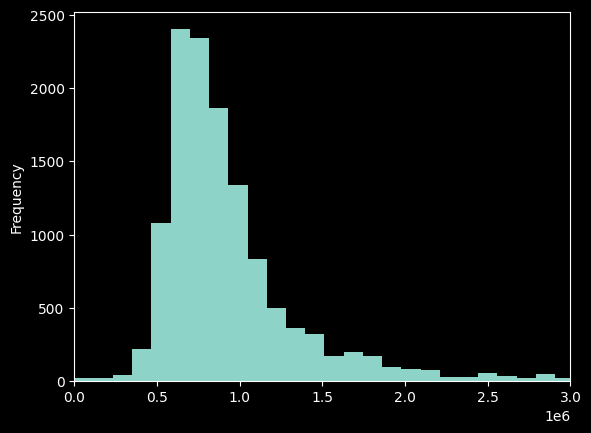

In [30]:
df['price'].plot.hist(bins = 30, xlim = (0,1000000))

# Kolumny

In [13]:
df.columns.values.tolist()

['_id',
 'agency__id',
 'agency_city',
 'agency_county',
 'agency_name',
 'agency_otodom_id',
 'agency_postal_code',
 'agency_province',
 'agency_street',
 'area',
 'auction_type',
 'building_build_year',
 'building_floors',
 'building_type',
 'created_at',
 'description',
 'developer_id',
 'estate_agency',
 'extras',
 'floor',
 'heating',
 'link',
 'localization_city',
 'localization_county',
 'localization_district',
 'localization_latitude',
 'localization_longitude',
 'localization_province',
 'localization_street',
 'market_type',
 'offered_by',
 'otodom_id',
 'photo_urls',
 'price',
 'price_per_meter',
 'promoted',
 'property_type',
 'rent',
 'construction_status',
 'rooms',
 'security_types',
 'title']

# Rozkłady wartości poszczególnych kolumn

## Rozkłady typów nieruchomości

### Liczbowo

In [5]:
df['property_type'].value_counts()

property_type
flat     12570
house      553
Name: count, dtype: int64

### Procentowo

In [7]:
round(df['property_type'].value_counts(normalize = True)*100)

property_type
flat     96.0
house     4.0
Name: proportion, dtype: float64

### Histogram

<Axes: xlabel='property_type'>

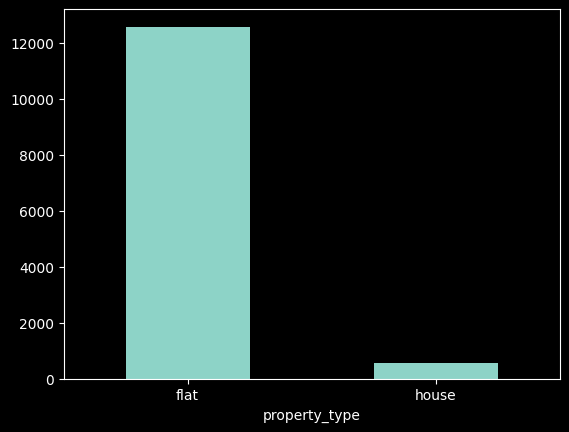

In [19]:
df['property_type'].value_counts().plot.bar(rot=0)

## Rozkłady podmiotu oferującego

### Liczbowo

In [5]:
df['offered_by'].value_counts()

offered_by
developer_unit    7374
agency            5028
private            721
Name: count, dtype: int64

### Procentowo

In [7]:
round(df['offered_by'].value_counts(normalize = True)*100)

offered_by
developer_unit    56.0
agency            38.0
private            5.0
Name: proportion, dtype: float64

### Histogram

<Axes: xlabel='offered_by'>

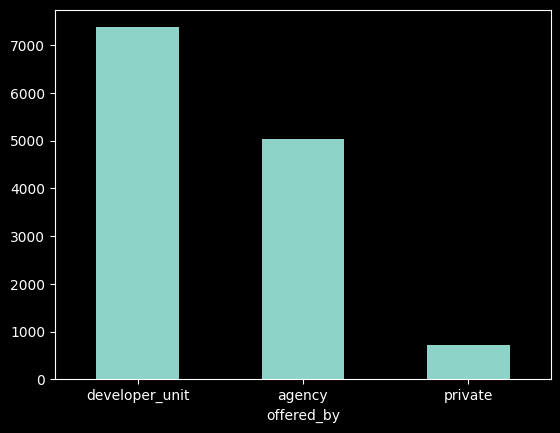

In [24]:
df['offered_by'].value_counts().plot.bar(rot=0)

## Rozkład ilości pokoi

In [17]:
df['rooms'].value_counts(dropna=False)

rooms
2.0     5131
3.0     4097
4.0     1711
1.0     1275
5.0      575
6.0      159
NaN       83
7.0       48
8.0       23
9.0       13
10.0       8
Name: count, dtype: int64

# Miary tendencji centralnej

## Cena za m^2

In [8]:
df.describe()['price_per_meter']

count    12595.000000
mean     16317.433347
std       4351.200198
min         41.000000
25%      14054.000000
50%      15800.000000
75%      17631.000000
max      79800.000000
Name: price_per_meter, dtype: float64

# Wykresy

## Area vs price

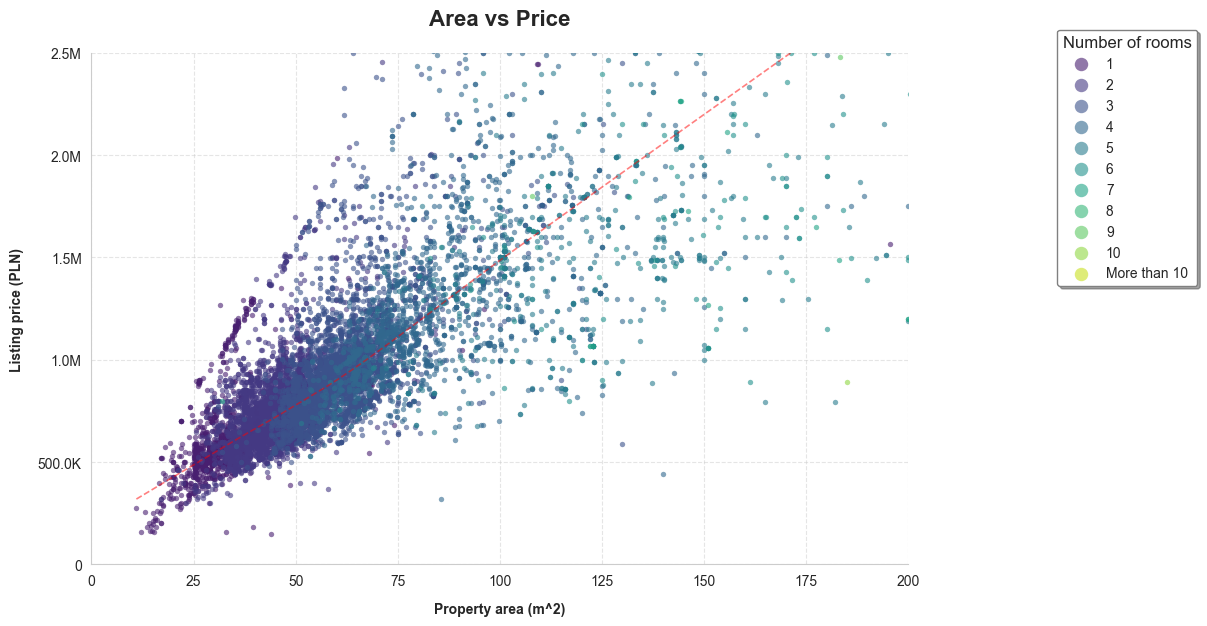

In [181]:
sns.set_style("whitegrid")

df_area_price = df[(df['price'] > dynamic_threshold) & (df['price'].isnull() == False)].copy()
area_price = sns.lmplot(data=df_area_price, x='area', y='price', 
                             hue='rooms_discrete', 
                             palette='viridis',
                        height=6, 
                        aspect=1.5,
                        ci=None, # Set to 95 if you want the shaded confidence interval
                        scatter_kws={'alpha': 0.6, 's': 15, 'linewidths': 0}, # Controls the dots
                        fit_reg=False   # Controls the lines
                       )

for ax in area_price.axes.flat:
    sns.regplot(
        data=df_area_price, 
        x='area', 
        y='price', 
        ax=ax, 
        scatter=False,
        lowess=True,# Don't draw the dots a second time
        color='red',   # Distinct color for the global average
        ci=None, 
        line_kws={'linewidth': 1.2, 'alpha': 0.5, 'linestyle': '--', 'label': 'Global Average'}
    )

area_price.set(
    xlim=(0, 200), 
    ylim=(0, 2500000),
)

area_price.ax.set_title("Area vs Price",
                     fontsize=16,
                     fontweight='bold',
                     pad=20)

area_price.set_xlabels("Property area (m^2)", 
                                 fontsize=10, 
                                 fontweight='semibold',
                                 labelpad=10)
area_price.set_ylabels("Listing price (PLN)", 
                                 fontsize=10, 
                                 fontweight='semibold',
                                 labelpad=10)

for ax in area_price.axes.flat:
    ax.yaxis.set_major_formatter(FuncFormatter(format_millions))
    ax.grid(True, linestyle='--', alpha=0.5)
sns.move_legend(area_price, 
                "upper left", 
                bbox_to_anchor=(1, 1), 
                title='Number of rooms',
                title_fontsize=12,      
                fontsize=10,            
                markerscale=2.5,        
                frameon=True,        
                shadow=True,            
                facecolor='white',   
                edgecolor='gray')
plt.show()



## Build year vs rent

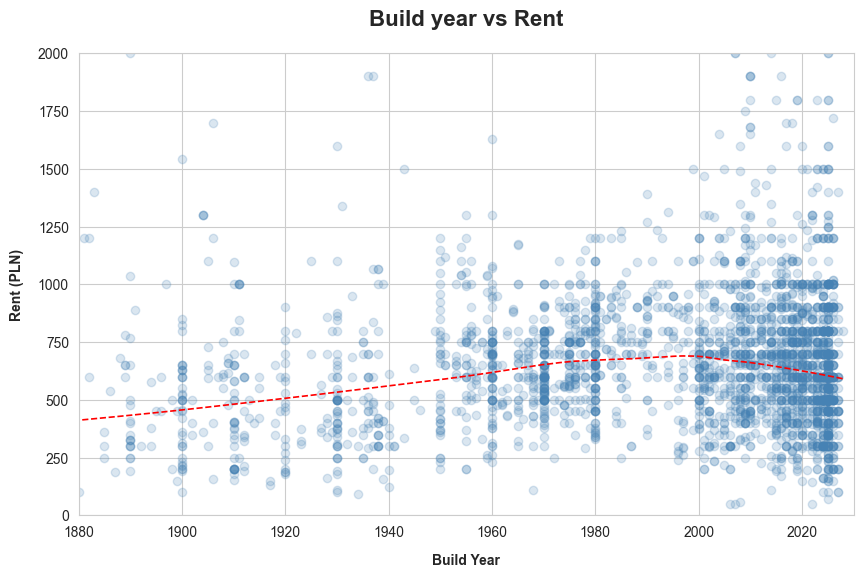

In [174]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
# year_rent = sns.scatterplot(data=df, x='building_build_year', y='rent')
#filtrowanie rekordów z rent < 20
df_rent = df[df['rent'] > rent_limit]
year_rent=sns.regplot(
        data=df_rent, 
        x='building_build_year', 
        y='rent',
        color='red',
        lowess=True,# Distinct color for the global average
        ci=None,
        scatter_kws={'alpha': 0.2, 'color': 'steelblue'},
        line_kws={'linewidth': 1.2, 'linestyle': '--', 'label': 'Global Average'}
    )
year_rent.set(
    xlim=(1880,2030),
    ylim=(0,2000),
    title="Build year vs rent",
)
year_rent.set_title("Build year vs Rent",
                     fontsize=16,
                     fontweight='bold',
                     pad=20)

year_rent.set_xlabel("Build Year", 
                                 fontsize=10, 
                                 fontweight='semibold',
                                 labelpad=10)
year_rent.set_ylabel("Rent (PLN)", 
                                 fontsize=10, 
                                 fontweight='semibold',
                                 labelpad=10)
plt.show()

## Price per m vs construction status

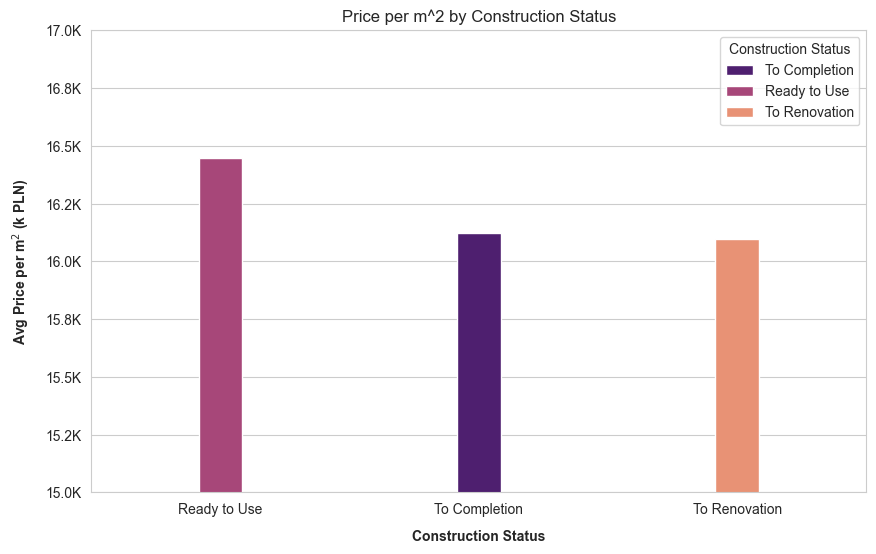

In [116]:
df_primary_market = df[df['market_type']=='primary']
#Mapa nazw
translation_map = {
    'ready_to_use': 'Ready to Use',
    'to_completion': 'To Completion',
    'to_renovation': 'To Renovation'
}
df_primary_market['construction_status'] = df_primary_market['construction_status'].map(translation_map)
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

price_m_construction = sns.barplot(
    data=df_primary_market,
    x='construction_status',
    y='price_per_meter',
    hue='construction_status',
    palette='magma',
    order=['Ready to Use','To Completion','To Renovation'],
    width=0.17,
    errorbar=None
)
price_m_construction.legend(title='Construction Status')

price_m_construction.set(
    ylim=(15000,17000),
    title="Price per m^2 by Construction Status",
    
)
price_m_construction.set_xlabel("Construction Status", 
                                 fontsize=10, 
                                 fontweight='semibold',
                                 labelpad=10)
price_m_construction.set_ylabel("Avg Price per m$^2$ (k PLN)", 
                                 fontsize=10, 
                                 fontweight='semibold',
                                 labelpad=10)


price_m_construction.yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.show()

## Heatmapa mieszkań - Cena za m^2

In [247]:
df_map = df.dropna(subset='price_per_meter')
heatmap = px.density_map(
        df_map,
        lat='localization_latitude',
        lon='localization_longitude',
        z='price_per_meter',
        radius=10,
        zoom=12,
        map_style="carto-positron",
        #color_continuous_scale="YlOrRd", # Yellow to Orange to Red
        color_continuous_scale='Magma',
        title="Price per m² Neighborhood Hotspots"
)
heatmap.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
heatmap.write_html("temp_map.html")

# Śmietnik

In [17]:
df[df['rent']>70000]

,_id,agency__id,agency_city,agency_county,agency_name,agency_otodom_id,agency_postal_code,agency_province,agency_street,area,auction_type,building_build_year,building_floors,building_type,created_at,description,developer_id,estate_agency,extras,floor,heating,link,localization_city,localization_county,localization_district,localization_latitude,localization_longitude,localization_province,localization_street,market_type,offered_by,otodom_id,photo_urls,price,price_per_meter,promoted,property_type,rent,construction_status,rooms,security_types,title,rooms_clean,rooms_discrete
5500,69e00b2e67fdb1930e2832cc,69dff88b75b7afdbd6dce56b,Kraków,NaN,Biuro Nieruchomości Norpol,870498.0,31-069,małopolskie,Koletek 12/10,28.38,sale,2008.0,6.0,apartment,2026-03-24 11:03:27+01:00,ENGLISH BELOW Nowoczesne mieszkanie zlokali...,NaN,69dff88b75b7afdbd6dce56b,"lift,separate_kitchen,air_conditioning",1,urban,https://www.otodom.pl/pl/oferta/studio-w-angel...,krakow,powiat-krakow,Stare Miasto,50.070908,19.944463,malopolskie,ul. Szlak,secondary,agency,67838739,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,760000.0,26779.0,False,flat,79134.0,ready_to_use,1,"closed_area,entryphone,monitoring","Studio w Angel City | centrum 28 m², idealne p...",1,1


In [42]:
#df[df['rent']<10].count()
df[(df['rent']<10) & (df['rent']>0)]

,_id,agency__id,agency_city,agency_county,agency_name,agency_otodom_id,agency_postal_code,agency_province,agency_street,area,auction_type,building_build_year,building_floors,building_type,created_at,description,developer_id,estate_agency,extras,floor,heating,link,localization_city,localization_county,localization_district,localization_latitude,localization_longitude,localization_province,localization_street,market_type,offered_by,otodom_id,photo_urls,price,price_per_meter,promoted,property_type,rent,construction_status,rooms,security_types,title,rooms_clean,rooms_discrete
3115,69dffb006dae8358ef11062b,69dff7c43da3e367a98ad549,Kraków,NaN,Grupa Gamp,896316.0,30-033,małopolskie,ul. Henryka Sienkiewicza 9/11,56.68,sale,2026.0,3.0,block,2025-11-02 02:43:38+01:00,Na sprzedaż przestronne trzypokojowe mieszkani...,NaN,69dff7c43da3e367a98ad549,"garden,garage,air_conditioning,lift,basement",0,urban,https://www.otodom.pl/pl/oferta/plaszow-nowe-3...,krakow,powiat-krakow,Płaszów,50.048577,19.986012,malopolskie,Koszykarska 20b,primary,agency,67406508,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,898378.0,15850.0,False,flat,3.0,to_completion,3,entryphone,"Płaszów, nowe 3 pok., ogród 52 m2, bezpośrednio!",3,3
3116,69dffb006dae8358ef11062c,69dff7c43da3e367a98ad549,Kraków,NaN,Grupa Gamp,896316.0,30-033,małopolskie,ul. Henryka Sienkiewicza 9/11,56.83,sale,2026.0,3.0,block,2025-11-02 02:43:38+01:00,Na sprzedaż przestronne trzypokojowe mieszkani...,NaN,69dff7c43da3e367a98ad549,"balcony,garage,air_conditioning,lift,basement",1,urban,https://www.otodom.pl/pl/oferta/plaszow-nowe-3...,krakow,powiat-krakow,Płaszów,50.048577,19.986012,malopolskie,Koszykarska 20b,primary,agency,67406509,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,899618.0,15830.0,False,flat,3.0,to_completion,3,entryphone,"Płaszów, nowe 3 pok., balkon 7,5 m2, bezpośred...",3,3
3233,69dffd966dae8358ef1106aa,69dff7c43da3e367a98ad549,Kraków,NaN,Grupa Gamp,896316.0,30-033,małopolskie,ul. Henryka Sienkiewicza 9/11,57.81,sale,2026.0,3.0,block,2025-11-02 23:29:06+01:00,Na sprzedaż przestronne dwupoziomowe trzypokoj...,NaN,69dff7c43da3e367a98ad549,"balcony,garage,air_conditioning,lift,two_store...",2,urban,https://www.otodom.pl/pl/oferta/plaszow-dwupoz...,krakow,powiat-krakow,Płaszów,50.048577,19.986012,malopolskie,Koszykarska 20b,primary,agency,67408165,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,913398.0,15800.0,False,flat,3.0,to_completion,3,entryphone,"Płaszów, dwupoziomowe, 58m2, 3 pokoje, balkon!",3,3
3376,69e000f56dae8358ef110742,69dff8216dae8358ef11058f,Kraków,NaN,BRACIA SADURSCY NIERUCHOMOŚCI - ODDZIAŁ RYNEK ...,10843467.0,30-716,małopolskie,Przewóz 47,42.53,sale,1930.0,4.0,tenement,2025-12-08 17:24:19+01:00,| Dwupoziomowe mieszkanie na Kazimierzu &ndas...,NaN,69dff8216dae8358ef11058f,NaN,4,gas,https://www.otodom.pl/pl/oferta/stylowe-poddas...,krakow,powiat-krakow,Stare Miasto,50.049499,19.939030,malopolskie,Paulińska,secondary,agency,67520432,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,930000.0,21867.0,False,flat,1.0,NaN,3,NaN,Stylowe poddasze 3-pokojowe w sercu Kazimierza,3,3
3657,69e008106dae8358ef11085e,69dff7c43da3e367a98ad549,Kraków,NaN,Grupa Gamp,896316.0,30-033,małopolskie,ul. Henryka Sienkiewicza 9/11,63.96,sale,2026.0,3.0,block,2026-02-07 01:21:35+01:00,Na sprzedaż przestronne dwupoziomowe trzypokoj...,NaN,69dff7c43da3e367a98ad549,"balcony,garage,air_conditioning,lift,two_store...",2,urban,https://www.otodom.pl/pl/oferta/plaszow-dwupoz...,krakow,powiat-krakow,Płaszów,50.048577,19.986012,malopolskie,Koszykarska 20b,primary,agency,67686337,https://ireland.apollo.olxcdn.com/v1/files/eyJ...,999694.0,15630.0,False,flat,3.0,to_completion,3,entryphone,"Płaszów, dwupoziomowe, 64m2, 3 pokoje, balkon!",3,3
4765,69dffaeb67fdb1930e282fd1,69dff7ec67fdb1930e282f2e,Kraków,NaN,Emmerson Lumico sp z o.o.,3521044.0,30-556,małopolskie,ul. Wodna 2D,50.57,sale,2026.0,1.0,NaN,2026-03-20 18:12:48+01:00,Nowa inwestycja przy ulicy Wąwozowej składa si...,NaN,69dff7ec67fdb1930e282f2e

In [ ]:
df[(df['rent']<10) & (df['rent']>0)][['market_type','offered_by']].value_counts()

In [43]:
df[df['rent']<=0].count()

_id                       858
agency__id                838
agency_city               838
agency_county               6
agency_name               838
agency_otodom_id          838
agency_postal_code        838
agency_province           838
agency_street             838
area                      858
auction_type              858
building_build_year       786
building_floors           728
building_type             607
created_at                858
description               858
developer_id                0
estate_agency             838
extras                    789
floor                     726
heating                   477
link                      858
localization_city         858
localization_county       858
localization_district     709
localization_latitude     858
localization_longitude    858
localization_province     858
localization_street       774
market_type               858
offered_by                858
otodom_id                 858
photo_urls                858
price     

In [45]:
df[df['rent']<=0][['market_type','offered_by','building_build_year']].value_counts()

market_type  offered_by  building_build_year
primary      agency      2026.0                 201
                         2025.0                 169
                         2027.0                  80
secondary    agency      2025.0                  49
primary      agency      2024.0                  31
secondary    agency      2024.0                  17
                         2026.0                  13
primary      agency      2028.0                  13
secondary    agency      2020.0                  12
                         1970.0                  11
                         1960.0                   9
primary      agency      2023.0                   8
secondary    agency      1980.0                   8
                         1920.0                   7
                         2021.0                   6
                         2000.0                   6
primary      private     2026.0                   6
secondary    agency      2014.0                   6
                   

In [70]:
df['construction_status'].value_counts(dropna=False)

construction_status
to_completion    8767
ready_to_use     3116
NaN               832
to_renovation     408
Name: count, dtype: int64

1033    https://www.otodom.pl/pl/oferta/komfortowe-2-p...
1034    https://www.otodom.pl/pl/oferta/komfortowe-3-p...
1035    https://www.otodom.pl/pl/oferta/komfortowe-4po...
1036    https://www.otodom.pl/pl/oferta/komfortowe-4po...
1243    https://www.otodom.pl/pl/oferta/pokoj-biurowy-...
1244    https://www.otodom.pl/pl/oferta/pokoj-biurowy-...
1245    https://www.otodom.pl/pl/oferta/pokoj-biurowy-...
1246    https://www.otodom.pl/pl/oferta/pokoj-biurowy-...
1247    https://www.otodom.pl/pl/oferta/lokal-uslugowy...
1248    https://www.otodom.pl/pl/oferta/pokoj-biurowy-...
1709    https://www.otodom.pl/pl/oferta/lokal-uslugowy...
1934    https://www.otodom.pl/pl/oferta/nowoczesne-stu...
1935    https://www.otodom.pl/pl/oferta/nowoczesne-wyg...
1936    https://www.otodom.pl/pl/oferta/nowy-apartamen...
1937    https://www.otodom.pl/pl/oferta/nowy-apartamen...
1938    https://www.otodom.pl/pl/oferta/nowy-apartamen...
1939    https://www.otodom.pl/pl/oferta/nowy-apartamen...
1940    https:

In [258]:
df[df['price'].isna() == True][['offered_by','price_per_meter']]

,offered_by,price_per_meter
449,developer_unit,NaN
450,developer_unit,NaN
451,developer_unit,NaN
452,developer_unit,NaN
453,developer_unit,NaN
454,developer_unit,NaN
455,developer_unit,NaN
456,developer_unit,NaN
457,developer_unit,NaN
458,developer_unit,NaN
